# Baseline Model

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [ ]:

from datetime import datetime

In [ ]:
# Import necessary libraries
import os
import json
import numpy as np
import pandas as pd
import h5py
import tensorflow as tf
from tensorflow.keras import layers, models
import keras.backend as K


print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Reprodutibilidade
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, f1_score



TF: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Model Choice

As a baseline model, we implement the reference architecture provided in the challenge description:
a **3-layer 1D Convolutional Neural Network (CNN)**.

The architecture consists of:
- Two convolution + max-pooling blocks (each pooling with factor 10),
- One final convolution layer producing a 1 Hz probability sequence (90 values per window).

This baseline is appropriate because:
1. It is the official benchmark model of the challenge.
2. It processes raw PSG signals sampled at 100 Hz without handcrafted features.
3. It outputs a 1 Hz segmentation mask aligned with the provided ground-truth labels.
4. It provides a simple reference point for comparison with more complex architectures.

The model does not incorporate recurrence or attention mechanisms by design.




## Feature Selection

Each training example consists of:
- **8 PSG channels** sampled at **100 Hz**, resulting in input tensors of shape `(9000, 8)` for each 90-second window.
- A **binary segmentation mask** of shape `(90,)`, sampled at 1 Hz.

No handcrafted features are used.
The only preprocessing step applied is **signal normalization**, performed prior to training.

Subject identifiers are provided separately and are used exclusively to perform a
**subject-wise train/validation split**, preventing data leakage.



In [31]:
# Paths
IN_PATH = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\00_pre files\02_processed\nights_train_norm.h5"

with h5py.File(IN_PATH, "r") as f:
    Xn_train_nights = f["X_nights"][:]      # (22, 1800000, 8)
    y_nights        = f["y_nights"][:]      # (22, 18000)
    subj_order      = f["subject_ids"][:]   # (22,)

print(Xn_train_nights.shape, y_nights.shape, subj_order.shape)

(22, 1800000, 8) (22, 18000) (22,)


In [32]:
def chunk_generator(X_nights, y_nights, chunk_sec=300, stride_sec=60, fs=100):
    chunk_len = chunk_sec * fs
    stride_len = stride_sec * fs

    n_nights, T, C = X_nights.shape
    assert y_nights.shape[0] == n_nights
    assert y_nights.shape[1] == T // fs, f"y needs to have {T//fs} steps (1Hz) per night"

    for n in range(n_nights):
        X = X_nights[n]   # (T, 8) at 100Hz
        y = y_nights[n]   # (T//100,) at 1Hz
        for start in range(0, T - chunk_len + 1, stride_len):
            end = start + chunk_len

            X_chunk = X[start:end]
            y_chunk = y[start//fs : end//fs]

            # sanity: garante alinhamento perfeito
            if y_chunk.shape[0] != chunk_sec:
                continue

            yield X_chunk.astype("float32"), y_chunk.astype("float32")


In [33]:
#overlap = chunk − stride = 300 − 60 = 240 seconds 80% overlap
# stride = 120s → overlap = 180s (60%)
# stride = 150s → overlap = 150s (50%)
# stride = 300s → overlap = 0 (no overlap, but worse coverage)
CHUNK_SEC = 300  #5-minute (300s) windows 
STRIDE_SEC = 60
FS = 100

gen = chunk_generator(Xn_train_nights, y_nights, chunk_sec=CHUNK_SEC, stride_sec=STRIDE_SEC, fs=FS)
Xc, yc = next(gen)
print(Xc.shape, yc.shape)          # (30000, 8) (300,)
print("chunk % ones:", yc.mean()*100)


(30000, 8) (300,)
chunk % ones: 5.33333346247673


In [39]:
def make_tf_dataset(X_nights, y_nights, chunk_sec=300, stride_sec=60, fs=100,
                    batch_size=4, shuffle_buffer=1024):
    chunk_len = chunk_sec * fs

    output_signature = (
        tf.TensorSpec(shape=(chunk_len, 8), dtype=tf.float32),
        tf.TensorSpec(shape=(chunk_sec,), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(
        lambda: chunk_generator(X_nights, y_nights, chunk_sec, stride_sec, fs),
        output_signature=output_signature
    )

    ds = ds.shuffle(shuffle_buffer, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [42]:
SEED = 42
rng = np.random.default_rng(SEED)
idx = np.arange(22)
rng.shuffle(idx)

n_train = int(0.7 * len(idx))  # 15
train_idx = idx[:n_train]
val_idx   = idx[n_train:]

X_trainN = Xn_train_nights[train_idx]
y_trainN = y_nights[train_idx]
X_valN   = Xn_train_nights[val_idx]
y_valN   = y_nights[val_idx]

In [43]:
train_ds = make_tf_dataset(X_trainN, y_trainN, chunk_sec=300, stride_sec=60, batch_size=4)
val_ds   = make_tf_dataset(X_valN,   y_valN,   chunk_sec=300, stride_sec=60, batch_size=4, shuffle_buffer=256)

In [44]:
CHUNK_SEC = 300
STRIDE_SEC = 60
BATCH_SIZE = 4

train_ds = make_tf_dataset(Xn_train_nights, y_nights, chunk_sec=CHUNK_SEC, stride_sec=STRIDE_SEC, batch_size=BATCH_SIZE)

for xb, yb in train_ds.take(1):
    print("batch X:", xb.shape, "batch y:", yb.shape)  # (4, 30000, 8) e (4, 300)


batch X: (4, 30000, 8) batch y: (4, 300)


In [45]:
# 1) conferência de comprimento (sempre verdadeiro)
assert xb.shape[1] == 300 * 100
assert yb.shape[1] == 300

# 2) sanity do balanceamento no batch
print("true % ones no batch:", float(tf.reduce_mean(yb)) * 100)


true % ones no batch: 4.250000044703484


## Implementation

Below we implement the 3-layer CNN baseline as specified by the challenge.
Two Conv1D + MaxPool1D blocks downsample the 100 Hz signal to 1 Hz, and the final
Conv1D layer outputs class probabilities for each of the 90 seconds.


CNN Baseline model

In [55]:
FS = 100
CHUNK_SEC = 300
N_SAMPLES = FS * CHUNK_SEC   # 30000
N_CHANNELS = 8

def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(N_SAMPLES, N_CHANNELS)),

        layers.Conv1D(32, kernel_size=25, padding='same', activation='relu'),
        layers.MaxPooling1D(pool_size=10),  # 9000 → 900

        layers.Conv1D(64, kernel_size=25, padding='same', activation='relu'),
        layers.MaxPooling1D(pool_size=10),  # 900 → 90

        layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid'),
        layers.Lambda(lambda t: tf.squeeze(t, axis=-1))  # (batch, 90)
    ])
    return model

model = build_baseline_cnn()
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 30000, 32)         6432      
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 3000, 32)         0         
 1D)                                                             
                                                                 
 conv1d_4 (Conv1D)           (None, 3000, 64)          51264     
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 300, 64)          0         
 1D)                                                             
                                                                 
 conv1d_5 (Conv1D)           (None, 300, 1)            193       
                                                                 
 lambda_1 (Lambda)           (None, 300)              

Loss Function (Weighted BCE)

In [56]:
positive_ratio = float(np.mean(y_trainN))
neg_ratio = 1.0 - positive_ratio
pos_weight = neg_ratio / (positive_ratio + 1e-12)
print("Positive ratio:", positive_ratio, "| pos_weight:", pos_weight)

def weighted_bce(pos_weight):
    def loss(y_true, y_pred):
        bce = K.binary_crossentropy(y_true, y_pred)
        w = 1.0 + (pos_weight - 1.0) * y_true
        return K.mean(bce * w)
    return loss


Positive ratio: 0.062044444444444444 | pos_weight: 15.117478509784998


Compile & Train

In [ ]:
lr = 1e-4  
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=weighted_bce(pos_weight),
    metrics=[tf.keras.metrics.AUC(curve="PR", name="auc_pr")]
)

OUT_DIR = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel"
os.makedirs(OUT_DIR, exist_ok=True)

ckpt_path = os.path.join(OUT_DIR, "baseline_best.keras")


run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = r"...\2_BaselineModel"
os.makedirs(OUT_DIR, exist_ok=True)

ckpt_best = os.path.join(OUT_DIR, f"{run_id}_best.keras")
ckpt_last = os.path.join(OUT_DIR, f"{run_id}_last.keras")



callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, save_best_only=True, monitor="val_loss", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
]


In [59]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
   1627/Unknown - 75s 44ms/step - loss: 1.3512 - accuracy: 0.0327
Epoch 1: val_loss improved from inf to 1.51373, saving model to C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel\baseline_best.keras
1628/1628 [==============================] - 89s 53ms/step - loss: 1.3508 - accuracy: 0.0327 - val_loss: 1.5137 - val_accuracy: 9.6525e-04 - lr: 1.0000e-04
Epoch 2/100
1627/1628 [============================>.] - ETA: 0s - loss: 1.3499 - accuracy: 0.0493
Epoch 2: val_loss did not improve from 1.51373
1628/1628 [==============================] - 82s 50ms/step - loss: 1.3495 - accuracy: 0.0498 - val_loss: 1.5445 - val_accuracy: 0.5014 - lr: 1.0000e-04
Epoch 3/100
1628/1628 [==============================] - ETA: 0s - loss: 1.3479 - accuracy: 0.0559
Epoch 3: val_loss did not improve from 1.51373
1628/1628 [==============================] - 84s 51ms/step - loss: 1.3479 - accuracy: 0.0559 - val_loss: 1.5223 - val_accuracy: 0.0019 - lr: 1.0000e-04
Epoch 4/100
1628/1628

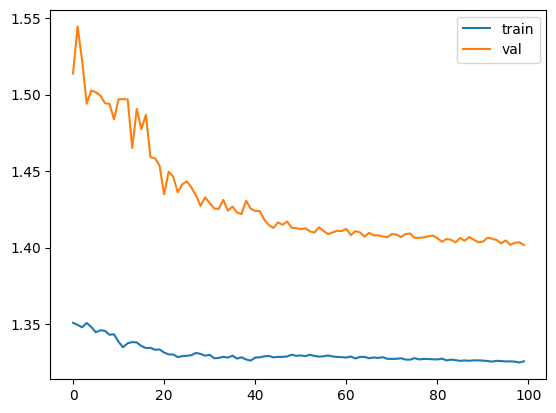

In [60]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.show()


## Evaluation

To establish a simple numerical baseline, we evaluate the model at the *window level* by
thresholding the predicted 1-Hz mask and assessing standard binary classification metrics:

- Accuracy
- Precision
- Recall
- F1-score

For this baseline notebook, we evaluate whether the window contains at least one apnea event.
The official challenge evaluation (event-level F1 with IoU)



In [65]:
import shutil, os
from datetime import datetime

OUT_DIR = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel"
src = os.path.join(OUT_DIR, "baseline_best.keras")

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
dst = os.path.join(OUT_DIR, f"{run_id}_BEST_frozen.keras")

shutil.copy2(src, dst)
print("BEST model frozen at:", dst)


BEST model frozen at: C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel\20251214_014656_BEST_frozen.keras


In [ ]:
best_frozen = r"C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel\20251214_014656_BEST_frozen.keras"

model = tf.keras.models.load_model(best_frozen, compile = False)
print("Modelo carregado:", best_frozen)


Modelo carregado: C:\Users\giuli\Documents\Open_Campus\Sleep_Apnea\2_BaselineModel\20251214_014656_BEST_frozen.keras


In [69]:
def predict_nights_overlap_mean(
    model,
    X_nights,                 # (n_nights, 1800000, 8)
    chunk_sec=300,
    stride_sec=60,
    fs=100,
    batch_size=4
):
    n_nights, T, C = X_nights.shape
    chunk_len = chunk_sec * fs        # 30000
    stride_len = stride_sec * fs      # 6000
    T1 = T // fs                      # 18000

    y_sum = np.zeros((n_nights, T1), dtype=np.float32)
    y_cnt = np.zeros((n_nights, T1), dtype=np.float32)

    for n in range(n_nights):
        X = X_nights[n]  # (1800000, 8)
        starts = range(0, T - chunk_len + 1, stride_len)

        batch_X = []
        batch_ranges = []

        for start in starts:
            end = start + chunk_len
            x_chunk = X[start:end]          # (30000, 8)

            s1 = start // fs
            e1 = end // fs                  # 300 pontos

            batch_X.append(x_chunk)
            batch_ranges.append((s1, e1))

            if len(batch_X) == batch_size:
                preds = model.predict(np.stack(batch_X).astype("float32"), verbose=0)  # (B, 300)
                for p, (s1_, e1_) in zip(preds, batch_ranges):
                    y_sum[n, s1_:e1_] += p
                    y_cnt[n, s1_:e1_] += 1.0
                batch_X, batch_ranges = [], []

        if batch_X:
            preds = model.predict(np.stack(batch_X).astype("float32"), verbose=0)
            for p, (s1_, e1_) in zip(preds, batch_ranges):
                y_sum[n, s1_:e1_] += p
                y_cnt[n, s1_:e1_] += 1.0

    return y_sum / np.maximum(y_cnt, 1.0)


In [70]:
y_pred_val_nights = predict_nights_overlap_mean(
    model,
    X_valN,
    chunk_sec=300,
    stride_sec=60,
    fs=100,
    batch_size=4
)

print(y_pred_val_nights.shape)  # esperado: (n_val, 18000)


(7, 18000)


In [72]:

print("y_pred_val_nights:", y_pred_val_nights.shape)  # (n_val, 18000)
print("min/max/mean:", y_pred_val_nights.min(), y_pred_val_nights.max(), y_pred_val_nights.mean())


y_pred_val_nights: (7, 18000)
min/max/mean: 0.20183344 0.9724482 0.49136212


In [78]:
def extract_events_from_binary_mask(binary_mask, fs=1):
    binary_mask = np.asarray(binary_mask).astype(int)
    padded = np.concatenate([[0], binary_mask, [0]])
    diff = np.diff(padded)
    starts = np.where(diff == 1)[0] / fs
    ends   = np.where(diff == -1)[0] / fs
    return [(float(s), float(e)) for s, e in zip(starts, ends)]

def jaccard_overlap(pred_events, true_events):
    # rows=true, cols=pred
    A = len(pred_events)
    B = len(true_events)
    if A == 0 or B == 0:
        return np.zeros((B, A), dtype=np.float32)

    p_start = np.array([s for s, e in pred_events])[None, :]
    p_end   = np.array([e for s, e in pred_events])[None, :]
    t_start = np.array([s for s, e in true_events])[:, None]
    t_end   = np.array([e for s, e in true_events])[:, None]

    inter = np.maximum(np.minimum(p_end, t_end) - np.maximum(p_start, t_start), 0.0)
    union = (p_end - p_start) + (t_end - t_start) - inter + 1e-12
    return (inter / union).astype(np.float32)

def tp_fp_fn(pred_events, true_events, min_iou=0.3):
    if len(pred_events) == 0:
        return 0, 0, len(true_events)
    if len(true_events) == 0:
        return 0, len(pred_events), 0

    iou = jaccard_overlap(pred_events, true_events)  # (n_true, n_pred)
    matched_true = int(np.any(iou >= min_iou, axis=1).sum())
    matched_pred = int(np.any(iou >= min_iou, axis=0).sum())

    tp = int(min(matched_true, matched_pred))
    fp = len(pred_events) - tp
    fn = len(true_events) - tp
    return tp, fp, fn

def event_f1_nights(y_pred_bin_nights, y_true_nights, min_iou=0.3):
    total_tp = total_fp = total_fn = 0
    for yp, yt in zip(y_pred_bin_nights, y_true_nights):
        pred_events = extract_events_from_binary_mask(yp, fs=1)
        true_events = extract_events_from_binary_mask(yt, fs=1)
        tp, fp, fn = tp_fp_fn(pred_events, true_events, min_iou=min_iou)
        total_tp += tp; total_fp += fp; total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-12)
    recall    = total_tp / (total_tp + total_fn + 1e-12)
    return float(2 * precision * recall / (precision + recall + 1e-12))


In [79]:
# y_valN deve ser (7, 18000) 0/1
y_true_val_nights = y_valN.astype(int)

best_t, best_f1 = None, -1
for t in np.linspace(0.20, 0.80, 31):
    yb = (y_pred_val_nights >= t).astype(int)
    f1 = event_f1_nights(yb, y_true_val_nights, min_iou=0.3)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("BEST threshold:", best_t)
print("BEST Event-F1:", best_f1)


BEST threshold: 0.5800000000000001
BEST Event-F1: 0.186413902053229


In [80]:
t = 0.58
yb = (y_pred_val_nights >= t).astype(int)

def count_events(mask_1hz):
    return len(extract_events_from_binary_mask(mask_1hz))

for i in range(yb.shape[0]):
    n_true = count_events(y_valN[i])
    n_pred = count_events(yb[i])
    print(f"night {i}: true_events={n_true:3d} | pred_events={n_pred:3d} | true%={y_valN[i].mean()*100:5.2f}% | pred%={yb[i].mean()*100:5.2f}%")


night 0: true_events= 20 | pred_events= 22 | true%= 1.39% | pred%= 0.37%
night 1: true_events= 96 | pred_events=  8 | true%= 9.56% | pred%= 0.09%
night 2: true_events=192 | pred_events=650 | true%=27.24% | pred%=51.87%
night 3: true_events= 21 | pred_events= 33 | true%= 1.63% | pred%= 0.57%
night 4: true_events= 16 | pred_events=  9 | true%= 2.90% | pred%= 0.18%
night 5: true_events= 18 | pred_events=  1 | true%= 1.63% | pred%= 0.04%
night 6: true_events=154 | pred_events= 26 | true%=13.77% | pred%= 0.43%


In [81]:
def postprocess_mask(mask, min_len=10, gap_fill=5):
    """
    mask: (T,) 0/1 em 1Hz
    min_len: remove eventos com duração < min_len segundos
    gap_fill: preenche buracos de zeros com duração <= gap_fill dentro de um evento
    """
    m = mask.astype(int).copy()
    T = len(m)

    # 1) fill small gaps (0-runs curtos entre 1s)
    i = 0
    while i < T:
        if m[i] == 0:
            j = i
            while j < T and m[j] == 0:
                j += 1
            gap = j - i
            left_one = (i - 1 >= 0 and m[i - 1] == 1)
            right_one = (j < T and m[j] == 1)
            if left_one and right_one and gap <= gap_fill:
                m[i:j] = 1
            i = j
        else:
            i += 1

    # 2) remove short events (1-runs curtos)
    i = 0
    while i < T:
        if m[i] == 1:
            j = i
            while j < T and m[j] == 1:
                j += 1
            run = j - i
            if run < min_len:
                m[i:j] = 0
            i = j
        else:
            i += 1

    return m


In [82]:
best = (-1, None)

for t in np.linspace(0.45, 0.75, 16):
    raw = (y_pred_val_nights >= t).astype(int)

    for min_len in [5, 10, 15]:
        for gap_fill in [0, 3, 5]:
            ypp = np.stack([postprocess_mask(raw[i], min_len=min_len, gap_fill=gap_fill)
                            for i in range(raw.shape[0])])
            f1 = event_f1_nights(ypp, y_valN.astype(int), min_iou=0.3)

            if f1 > best[0]:
                best = (f1, (t, min_len, gap_fill))

print("BEST postproc Event-F1:", best[0])
print("params (t, min_len, gap_fill):", best[1])


BEST postproc Event-F1: 0.2513426423195915
params (t, min_len, gap_fill): (0.5700000000000001, 10, 0)
